In [2]:
from pathlib import Path
from collections import Counter
import json
import math
import random
import shutil
import xml.etree.ElementTree as ET

import matplotlib.pylab as plt
from matplotlib.patches import Rectangle
import numpy as np
from PIL import Image

**configuration**

In [3]:
SEED = 42
CLASS_TO_ID = {
    "D00": 0,
    "D10": 1,
    "D20": 2,
    "D40": 3,
}

CLASS_NAMES = {
    "D00": "Longitudinal crack",
    "D10": "Transverse crack",
    "D20": "Alligator crack",
    "D40": "Pothole",
}
REVIEWED_IGNORED_CLASSES = set()
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png",}

In [4]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


RAW_DATASET_DIR = Path("/content/RDD2022_China_MotorBike/China_MotorBike")

TRAIN_IMAGES_DIR = (RAW_DATASET_DIR / "train" / "images")
TRAIN_XML_DIR = (RAW_DATASET_DIR / "train" / "annotations" / "xmls")
TEST_IMAGES_DIR = (RAW_DATASET_DIR / "test" / "images")


PROCESSED_ALL_DIR = (PROJECT_ROOT / "data" / "processed" / "all")
PROCESSED_IMAGES_DIR = (PROCESSED_ALL_DIR / "images")
PROCESSED_LABELS_DIR = (PROCESSED_ALL_DIR / "labels")


REPORTS_DIR = (PROJECT_ROOT / "reports")
FIGURES_DIR = (REPORTS_DIR / "figures")


print("Project root :", PROJECT_ROOT)
print("Dataset root:", RAW_DATASET_DIR)
print("Train images:", TRAIN_IMAGES_DIR)
print("Train XMLs  :", TRAIN_XML_DIR)
print("Test images :", TEST_IMAGES_DIR)

Project root : /content
Dataset root: /content/RDD2022_China_MotorBike/China_MotorBike
Train images: /content/RDD2022_China_MotorBike/China_MotorBike/train/images
Train XMLs  : /content/RDD2022_China_MotorBike/China_MotorBike/train/annotations/xmls
Test images : /content/RDD2022_China_MotorBike/China_MotorBike/test/images


**File inventory and pairing audit**

In [5]:
def collect_images(directory):
    return sorted(
        path for path in directory.iterdir() if (
            path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
        )
    )

image_files = collect_images(TRAIN_IMAGES_DIR)
xml_files = sorted(TRAIN_XML_DIR.glob("*.xml"))
test_image_files = collect_images(TEST_IMAGES_DIR)

image_stems = [path.stem for path in image_files]
xml_stems = [path.stem for path in xml_files]

In [6]:
duplicate_image_stems = [
    stem for stem, count in Counter(image_stems).items() if count > 1
]
duplicate_xml_stems = [
    stem for stem, count in Counter(xml_stems).items() if count > 1
]

images_by_stem = {path.stem: path for path in image_files}
xml_by_stem = {path.stem: path for path in xml_files}

In [7]:
images_without_xml = sorted(set(images_by_stem) - set(xml_by_stem))

xml_without_images = sorted(set(xml_by_stem) - set(images_by_stem))

print("Train images       :", len(image_files))
print("Train XML files    :", len(xml_files))
print("Test images        :", len(test_image_files))
print("Images without XML :", len(images_without_xml))
print("XML without image  :", len(xml_without_images))
print("Duplicate images   :", len(duplicate_image_stems))
print("Duplicate XMLs     :", len(duplicate_xml_stems))

Train images       : 1977
Train XML files    : 1977
Test images        : 500
Images without XML : 0
XML without image  : 0
Duplicate images   : 0
Duplicate XMLs     : 0


**Parse and validate Pascal VOC annotations**

In [8]:
def read_required_number(node, path):
    text = node.findtext(path)
    
    if text is None:
        raise ValueError(f"Missing XML field: {path}")
    
    text = text.strip()
    if not text:
        raise ValueError(f"Empty XML field: {path}")
        
    value = float(text)
    if not math.isfinite(value):
        raise ValueError(f"Non-finite value in field: {path}")

    return value

In [9]:
records = []

audit_errors = []
ignored_class_counts = Counter()
target_class_counts = Counter()
images_per_class = Counter()

box_widths = []
box_heights = []
relative_box_areas = []

very_small_box_count = 0
empty_target_image_count = 0
duplicate_annotation_count = 0

In [10]:
for stem in sorted(image_stems):
    image_path = images_by_stem[stem]
    xml_path = xml_by_stem[stem]
    
    try:
        with Image.open(image_path) as image:
            image.load()
            actual_width, actual_height = image.size
    except Exception as error:
        audit_errors.append(f"{stem}: unreadable image — {error}")
        continue
    
    try:
        root = ET.parse(xml_path).getroot()
    except Exception as error:
        audit_errors.append(f"{stem}: malformed XML — {error}")
        continue
    
    # XML filename check.
    xml_filename = (root.findtext("filename") or "").strip()
    if xml_filename and Path(xml_filename).stem != stem:
        audit_errors.append(
            f"{stem}: XML filename says {xml_filename}"
        )
    
    # XML image-size check.
    try:
        xml_width = int(read_required_number(root, "size/width"))
        xml_height = int(read_required_number(root, "size/height"))
    except Exception as error:
        audit_errors.append(
            f"{stem}: invalid XML size — {error}"
        )
        continue
    
    if xml_width != actual_width or xml_height != actual_height:
        audit_errors.append(
            f"{stem}: XML size {xml_width}x{xml_height}, "
            f"actual size {actual_width}x{actual_height}"
        )

    target_objects = []
    classes_in_this_image = set()
    seen_annotations = set()

    for object_index, object_node in enumerate(root.findall("object")):
        class_code = (object_node.findtext("name") or "").strip()
        if not class_code:
            audit_errors.append(
                f"{stem}: object {object_index} has no class name"
            )
            continue

        if class_code not in CLASS_TO_ID:
            ignored_class_counts[class_code] += 1
            continue

        bbox_node = object_node.find("bndbox")
        if bbox_node is None:
            audit_errors.append(
                f"{stem}: {class_code} has no bndbox"
            )
            continue

        try:
            x1 = read_required_number(bbox_node, "xmin")
            y1 = read_required_number(bbox_node, "ymin")
            x2 = read_required_number(bbox_node, "xmax")
            y2 = read_required_number(bbox_node, "ymax")
        except Exception as error:
            audit_errors.append(
                f"{stem}: invalid box — {error}"
            )
            continue

        if x2 <= x1 or y2 <= y1:
            audit_errors.append(
                f"{stem}: invalid {class_code} box [{x1}, {y1}, {x2}, {y2}]"
            )
            continue

        if x1 < 0 or y1 < 0 or x2 > actual_width or y2 > actual_height:
            audit_errors.append(
                f"{stem}: out-of-bounds {class_code} box [{x1}, {y1}, {x2}, {y2}] "
                f"for image {actual_width}x{actual_height}"
            )
            continue

        annotation_key = (class_code, x1, y1, x2, y2)

        if annotation_key in seen_annotations:
            duplicate_annotation_count += 1
            audit_errors.append(
                f"{stem}: exact duplicate annotation {annotation_key}"
            )
            continue

        seen_annotations.add(annotation_key)

        box_width = x2 - x1
        box_height = y2 - y1

        relative_area = (box_width * box_height / (actual_width * actual_height))

        if box_width < 2 or box_height < 2:
            very_small_box_count += 1

        box_widths.append(box_width)
        box_heights.append(box_height)
        relative_box_areas.append(relative_area)

        target_class_counts[class_code] += 1
        classes_in_this_image.add(class_code)

        target_objects.append({
            "class_code": class_code,
            "class_id": CLASS_TO_ID[class_code],
            "box_xyxy": [x1, y1, x2, y2],
        })

    if not target_objects:
        empty_target_image_count += 1

    images_per_class.update(classes_in_this_image)
    records.append({
        "stem": stem,
        "image_path": image_path,
        "xml_path": xml_path,
        "width": actual_width,
        "height": actual_height,
        "objects": target_objects,
    })

In [11]:
print("Parsed image records :", len(records))
print("Target objects       :", sum(target_class_counts.values()))
print("Empty target images  :", empty_target_image_count)
print("Very small boxes     :", very_small_box_count)
print("Duplicate boxes      :", duplicate_annotation_count)

print("\nTarget class counts:")
for class_code in CLASS_TO_ID:
    print(
        f"{class_code} "
        f"({CLASS_NAMES[class_code]:<20}): "
        f"{target_class_counts[class_code]}"
    )

print("\nNon-target/unknown classes:")
if ignored_class_counts:
    for class_code, count in ignored_class_counts.items():
        print(f"{class_code}: {count}")
else:
    print("None")

Parsed image records : 1977
Target objects       : 4650
Empty target images  : 43
Very small boxes     : 0
Duplicate boxes      : 0

Target class counts:
D00 (Longitudinal crack  ): 2678
D10 (Transverse crack    ): 1096
D20 (Alligator crack     ): 641
D40 (Pothole             ): 235

Non-target/unknown classes:
Repair: 277


In [12]:
if audit_errors:
    print(
        f"Found {len(audit_errors)} critical errors."
    )

    for error in audit_errors[:25]:
        print("-", error)

In [13]:
observed_non_target_classes = set(ignored_class_counts)

unreviewed_classes = (observed_non_target_classes
 - REVIEWED_IGNORED_CLASSES
)

if unreviewed_classes:
    print("Unreviewed classes:", unreviewed_classes)

Unreviewed classes: {'Repair'}


**Box-size and class-distribution inspection**

In [14]:
def print_quantiles(name, values):
    if not values:
        print(f"{name}: no values")
        return

    values = np.asarray(values, dtype=np.float32,)
    quantile_points = [
        0.00,
        0.25,
        0.50,
        0.75,
        1.00,
    ]

    quantile_values = np.quantile(values, quantile_points)
    print(f"\n{name}")

    for point, value in zip(
        quantile_points,
        quantile_values,
    ):
        print(f"q={point:.2f}: {value:.6f}")

In [15]:
print_quantiles("Box widths in pixels", box_widths)
print_quantiles("Box heights in pixels",box_heights)
print_quantiles("Relative box areas",relative_box_areas)


Box widths in pixels
q=0.00: 4.000000
q=0.25: 43.000000
q=0.50: 96.000000
q=0.75: 194.750000
q=1.00: 511.000000

Box heights in pixels
q=0.00: 6.000000
q=0.25: 46.000000
q=0.50: 104.000000
q=0.75: 259.000000
q=1.00: 511.000000

Relative box areas
q=0.00: 0.000206
q=0.25: 0.013012
q=0.50: 0.041777
q=0.75: 0.113799
q=1.00: 0.898632


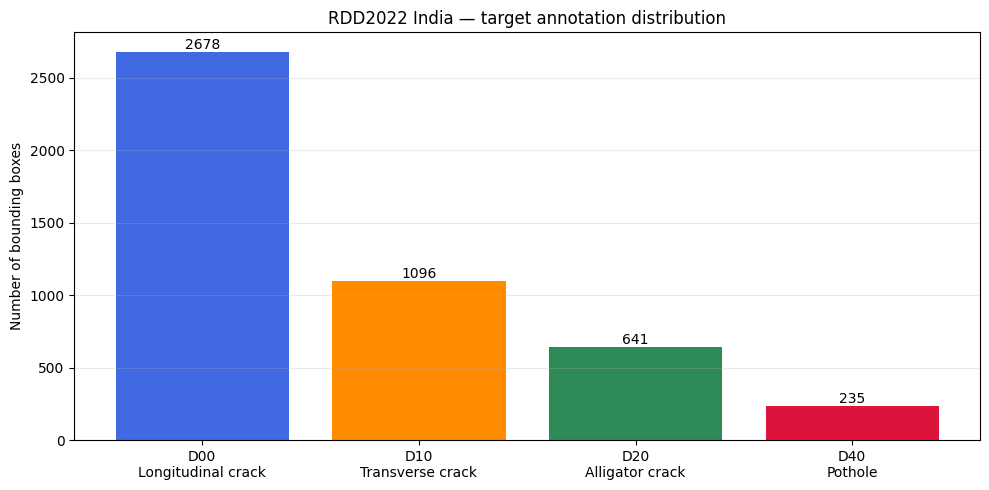

In [16]:
class_codes = list(CLASS_TO_ID)
counts = [target_class_counts[code]for code in class_codes]

labels = [
    f"{code}\n{CLASS_NAMES[code]}"
    for code in class_codes
]

plt.figure(figsize=(10, 5))
bars = plt.bar(
    labels,
    counts,
    color=[
        "royalblue",
        "darkorange",
        "seagreen",
        "crimson",
    ],
)
plt.title("RDD2022 India — target annotation distribution")
plt.ylabel("Number of bounding boxes")
plt.grid(axis="y", alpha=0.25)
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

**Visualize original XML annotations**

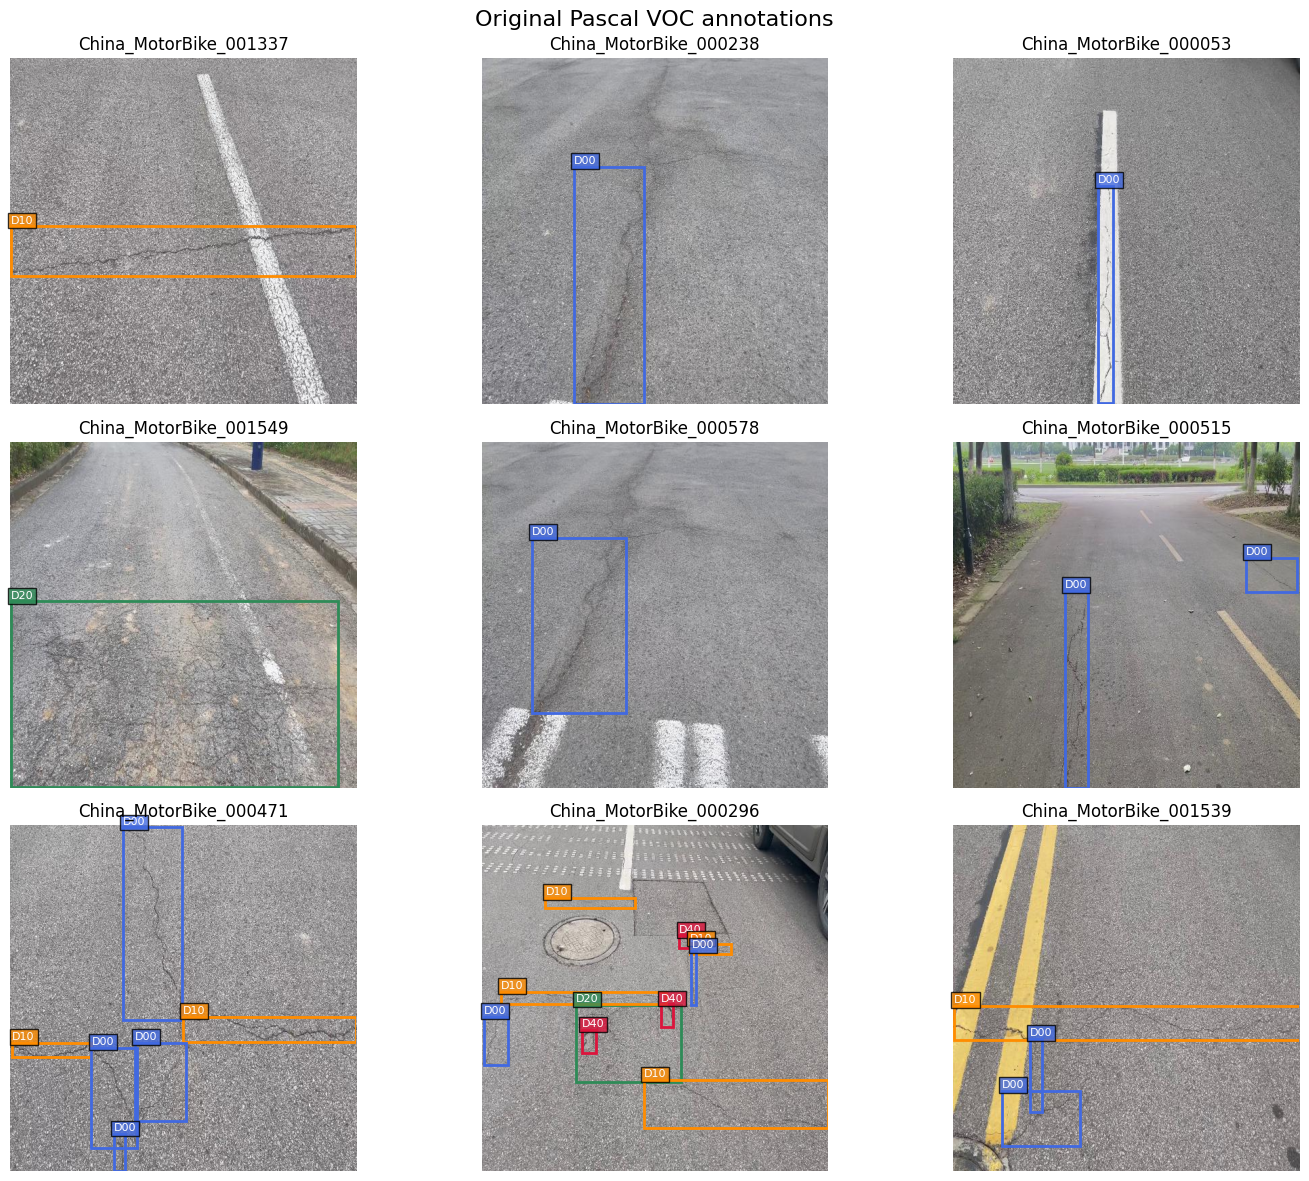

In [17]:
COLORS = {
    "D00": "royalblue",
    "D10": "darkorange",
    "D20": "seagreen",
    "D40": "crimson",
}

positive_records = [record for record in records if record["objects"]]
sample_count = min(9, len(positive_records),)

sample_records = random.Random(SEED).sample(positive_records,
sample_count)

fig, axes = plt.subplots(3, 3, figsize=(15, 12),)

axes = axes.flatten()
for axis in axes:
    axis.axis("off")

for axis, record in zip(axes, sample_records,):
    with Image.open(
        record["image_path"]
    ) as image:
        rgb_image = image.convert("RGB")
        axis.imshow(rgb_image)

    for annotation in record["objects"]:
        x1, y1, x2, y2 = annotation["box_xyxy"]
        class_code = annotation["class_code"]

        axis.add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
                edgecolor=COLORS[class_code],
            )
        )

        axis.text(
            x1,
            max(0, y1 - 4),
            class_code,
            color="white",
            fontsize=8,
            bbox={
                "facecolor": COLORS[class_code],
                "alpha": 0.8,
                "pad": 2,
            },
        )

    axis.set_title(record["stem"])
    axis.axis("off")

plt.suptitle(
    "Original Pascal VOC annotations",
    fontsize=16,
)

plt.tight_layout()
plt.show()

**XML XYXY → YOLO normalized CXCYWH**

In [18]:
def xyxy_to_yolo(xyxy, image_width, image_height):
    x1, y1, x2, y2 = xyxy
    
    center_x = (
        (x1 + x2) / 2
    ) / image_width
    
    center_y = (
        (y1 + y2) / 2
    ) / image_height
    
    box_width = (x2 - x1) / image_width
    box_height = (y2 - y1) / image_height
    
    result = [center_x, center_y, box_width, box_height]
    if not (
        0 <= center_x <= 1
        and 0 <= center_y <= 1
        and 0 < box_width <= 1
        and 0 < box_height <= 1
    ):
        raise ValueError(
            f"Invalid normalized box: {result}"
        )

    return result

_Reverse conversion_

In [19]:
def yolo_to_xyxy(cxcywh, image_width, image_height):
    center_x, center_y, box_width, box_height = cxcywh
    
    center_x *= image_width
    center_y *= image_height
    
    box_width *= image_width
    box_height *= image_height
    
    x1 = center_x - box_width / 2
    y1 = center_y - box_height / 2
    x2 = center_x + box_width / 2
    y2 = center_y + box_height / 2

    return [x1, y1, x2, y2]

In [20]:
for record in records:
    for annotation in record["objects"]:
        original_box = annotation["box_xyxy"]
        
        yolo_box = xyxy_to_yolo(
            original_box, record["width"], record["height"]
        )
        
        reconstructed_box = yolo_to_xyxy(
            yolo_box, record["width"], record["height"]
        )
        
        np.testing.assert_allclose(reconstructed_box, original_box, rtol=0, atol=1e-5)

**Create YOLO dataset**

In [21]:
PROCESSED_IMAGES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROCESSED_LABELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [22]:
for record in records:
    destination_image = (
        PROCESSED_IMAGES_DIR / record["image_path"].name
    )
    destination_label = (
        PROCESSED_LABELS_DIR / f"{record["stem"]}.txt"
    )
    shutil.copy2(
        record["image_path"], destination_image
    )
    label_lines = []
    
    for annotation in record["objects"]:
        normalized_box = xyxy_to_yolo(
            annotation["box_xyxy"],
            record["width"],
            record["height"]
        )
        
        center_x, center_y, box_width, box_height = (
            normalized_box
        )
        
        label_lines.append(
            f"{annotation['class_id']} "
            f"{center_x:.8f} "
            f"{center_y:.8f} "
            f"{box_width:.8f} "
            f"{box_height:.8f}"
        )
        label_text = "\n".join(label_lines)
        if label_text:
            label_text += "\n"
        
        destination_label.write_text(
            label_text, encoding="utf-8"
        )

**Validate generated YOLO files**

In [ ]:
processed_images = sorted(
    path for path in PROCESSED_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_SUFFIXES
)

processed_labels = sorted(PROCESSED_LABELS_DIR.glob("*.txt"))

print("Processed images:", len(processed_images))
print("Processed labels:", len(processed_labels))

Processed images: 1977
Processed labels: 1934


In [ ]:
processed_image_stems = {
    path.stem for path in processed_images
}

processed_label_stems = {
    path.stem for path in processed_labels
}

In [ ]:
valid_class_ids = set(CLASS_TO_ID.values())
label_errors = []
empty_label_count = 0
converted_object_count = 0

for label_path in processed_labels:
    text = label_path.read_text(
        encoding="utf-8"
    ).strip()

    if not text:
        empty_label_count += 1
        continue

    for line_number, line in enumerate(
        text.splitlines(),
        start=1,
    ):
        parts = line.split()

        if len(parts) != 5:
            label_errors.append(
                f"{label_path.name}, line {line_number}: "
                f"expected 5 values, found {len(parts)}"
            )
            continue

        try:
            class_id = int(parts[0])

            center_x, center_y, box_width, box_height = (
                map(float, parts[1:])
            )

        except ValueError:
            label_errors.append(
                f"{label_path.name}, line {line_number}: "
                "non-numeric value"
            )
            continue

        if class_id not in valid_class_ids:
            label_errors.append(
                f"{label_path.name}, line {line_number}: "
                f"invalid class ID {class_id}"
            )

        if not (
            0 <= center_x <= 1
            and 0 <= center_y <= 1
            and 0 < box_width <= 1
            and 0 < box_height <= 1
        ):
            label_errors.append(
                f"{label_path.name}, line {line_number}: "
                "normalized coordinates out of range"
            )

        converted_object_count += 1

In [26]:
print("Converted objects :", converted_object_count)
print("Empty label files :", empty_label_count)
print("Label errors      :", len(label_errors))

if label_errors:
    for error in label_errors[:25]:
        print("-", error)

    raise RuntimeError(
        "Generated YOLO labels failed validation."
    )

if converted_object_count != sum(
    target_class_counts.values()
):
    raise RuntimeError(
        "Source and converted object counts do not match."
    )

print("Generated YOLO dataset passed numeric validation.")

Converted objects : 4650
Empty label files : 0
Label errors      : 0
Generated YOLO dataset passed numeric validation.


**Visualize converted YOLO labels**

In [29]:
def read_yolo_label(label_path, image_width, image_height,):
    annotations = []
    text = label_path.read_text(
        encoding="utf-8"
    ).strip()

    if not text:
        return annotations

    id_to_class = {
        class_id: class_code
        for class_code, class_id
        in CLASS_TO_ID.items()
    }

    for line in text.splitlines():
        parts = line.split()
        class_id = int(parts[0])
        normalized_box = list(
            map(float, parts[1:])
        )

        box_xyxy = yolo_to_xyxy(
            normalized_box,
            image_width,
            image_height,
        )

        annotations.append({
            "class_code": id_to_class[class_id],
            "box_xyxy": box_xyxy,
        })

    return annotations

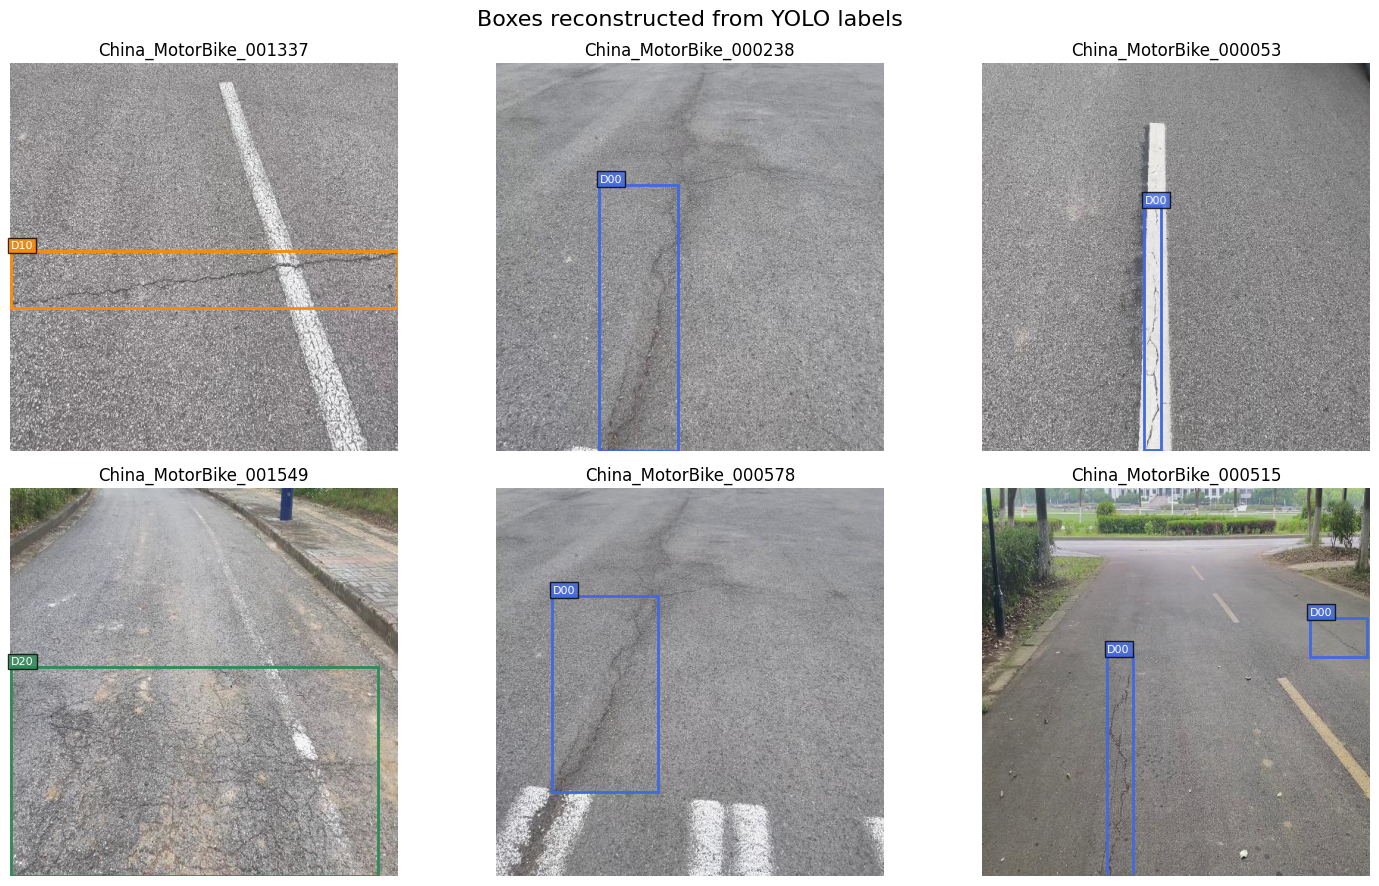

In [30]:
converted_positive_labels = [
    path for path in processed_labels
    if path.read_text(
        encoding="utf-8"
    ).strip()
]

sample_labels = random.Random(
    SEED
).sample(
    converted_positive_labels,
    min(6, len(converted_positive_labels)),
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9),)
axes = axes.flatten()

for axis in axes:
    axis.axis("off")

for axis, label_path in zip(axes, sample_labels,):
    image_path = images_by_stem[label_path.stem]
    with Image.open(image_path) as image:
        rgb_image = image.convert("RGB")
        image_width, image_height = image.size

    annotations = read_yolo_label(
        label_path,
        image_width,
        image_height,
    )

    axis.imshow(rgb_image)
    for annotation in annotations:
        x1, y1, x2, y2 = annotation["box_xyxy"]
        class_code = annotation["class_code"]

        axis.add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
                edgecolor=COLORS[class_code],
            )
        )

        axis.text(
            x1,
            max(0, y1 - 4),
            class_code,
            color="white",
            fontsize=8,
            bbox={
                "facecolor": COLORS[class_code],
                "alpha": 0.8,
                "pad": 2,
            },
        )

    axis.set_title(label_path.stem)
    axis.axis("off")

plt.suptitle(
    "Boxes reconstructed from YOLO labels",
    fontsize=16,
)

plt.tight_layout()
plt.show()

**Save audit summary**

In [31]:
def quantile_summary(values):
    if not values:
        return {}

    array = np.asarray(
        values,
        dtype=np.float32,
    )

    return {
        "min": float(np.min(array)),
        "q25": float(np.quantile(array, 0.25)),
        "median": float(np.median(array)),
        "q75": float(np.quantile(array, 0.75)),
        "max": float(np.max(array)),
    }

In [32]:
audit_report = {
    "training_images": len(image_files),
    "training_xmls": len(xml_files),
    "test_images_without_labels": len(test_image_files),
    "target_objects": int(
        sum(target_class_counts.values())
    ),
    "empty_target_images": empty_target_image_count,
    "very_small_boxes": very_small_box_count,
    "class_counts": dict(target_class_counts),
    "images_per_class": dict(images_per_class),
    "reviewed_ignored_class_counts": dict(
        ignored_class_counts
    ),
    "box_width_pixels": quantile_summary(
        box_widths
    ),
    "box_height_pixels": quantile_summary(
        box_heights
    ),
    "relative_box_area": quantile_summary(
        relative_box_areas
    ),
    "processed_images": len(processed_images),
    "processed_labels": len(processed_labels),
    "converted_objects": converted_object_count,
}

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

report_path = (
    REPORTS_DIR
    / "rdd2022_audit.json"
)

report_path.write_text(
    json.dumps(
        audit_report,
        indent=2,
    ),
    encoding="utf-8",
)

print("Audit report:", report_path.resolve())

Audit report: /content/reports/rdd2022_audit.json
